## Initialization Libraries.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Understanding the Basics

## What is Probability?
Probability is the measure of how likely an event is to occur. It ranges from **0 (impossible)** to **1 (certain)**.

## Key Probability Terminology
- **Experiment**: Process that produces outcomes (e.g., exam result)
- **Sample Space (S)**: All possible outcomes
- **Event (E)**: A subset of outcomes
- **Probability (P(E))**: Likelihood of event E

## Examples from Dataset
1. Probability that a student **passes the exam**
2. Probability that a student has **attendance > 80%**
3. Probability that a student **participates in group discussion**

---

# 2. Types of Events

## Empirical Probability (from data)

P(Pass) = Number of students who passed / Total students = 0.87

## Theoretical Probability (example)

Let probability of passing = p = 0.87

For 1 student:
P(Pass) = 0.87

---

# 3. Random Variable & Probability Distribution

Let X = number of students passing out of 3 students

X follows Binomial Distribution:
X ~ Binomial(n=3, p=0.87)

## Probability Distribution Table

| X (Pass) | Probability |
|----------|------------|
| 0        | 0.002      |
| 1        | 0.030      |
| 2        | 0.227      |
| 3        | 0.658      |

## Mean & Variance

Mean = np = 3 × 0.87 = 2.61  
Variance = np(1 − p) = 3 × 0.87 × 0.13 = 0.339

---

# 4. Venn Diagram Explanation

Define:
- A = Students studying >10 hours
- B = Students with attendance >80%

A ∩ B = Students satisfying both conditions

The overlapping region represents students who study more and attend regularly.

---

# 5. Contingency Table & Probabilities

## Contingency Table

| Group Discussion | Pass | Fail |
|------------------|------|------|
| Yes              | 93   | 6    |
| No               | 81   | 20   |

## Joint Probability

P(Discussion AND Pass) = 0.465

## Marginal Probability

P(Pass) = 0.87

## Conditional Probability

P(Pass | Discussion) = 0.939

---

# 6. Understanding Relationships

## Interpretation
Students who participate in group discussions have a very high probability (~94%) of passing.

## Are Events Independent?
No, they are dependent events.

Because:
P(Pass | Discussion) ≠ P(Pass)

---

# 7. Bayes Theorem Application

Given:
- P(High Attendance | Pass) = 0.70
- P(High Attendance | Fail) = 0.40
- P(High Attendance) = 0.60

We need to find:
P(Pass | High Attendance)

## Bayes Theorem Formula

P(Pass | High) = [P(High | Pass) × P(Pass)] / P(High)

## Calculation

P(Pass) = 0.87  
P(Fail) = 0.13  

P(High) = (0.70 × 0.87) + (0.40 × 0.13)  
= 0.609 + 0.052  
= 0.661  

P(Pass | High) = (0.70 × 0.87) / 0.661  
= 0.923  

## Final Answer

P(Pass | High Attendance) ≈ 0.92

---

# Conclusion

- Passing rate is very high (~87%)
- Group discussion strongly improves success
- Attendance also significantly impacts results
- Events are dependent, not independent

In [5]:
df = pd.read_csv("student_dataset.csv")
df

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,13,41.5,No,47,Fail
1,3,84.4,Yes,71,Pass
2,3,54.0,Yes,69,Pass
3,14,65.2,No,71,Pass
4,1,88.3,No,54,Fail
...,...,...,...,...,...
195,4,67.2,No,71,Pass
196,18,79.3,No,73,Pass
197,6,81.4,Yes,61,Pass
198,17,46.0,No,68,Pass


In [7]:
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,13,41.5,No,47,Fail
1,3,84.4,Yes,71,Pass
2,3,54.0,Yes,69,Pass
3,14,65.2,No,71,Pass
4,1,88.3,No,54,Fail


In [8]:
df.tail()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
195,4,67.2,No,71,Pass
196,18,79.3,No,73,Pass
197,6,81.4,Yes,61,Pass
198,17,46.0,No,68,Pass
199,8,63.9,Yes,98,Pass


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   study_hours          200 non-null    int64  
 1   attendance           200 non-null    float64
 2   group_discussion     200 non-null    object 
 3   previous_test_score  200 non-null    int64  
 4   final_exam_pass      200 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 7.9+ KB
None


In [10]:
print(df.dtypes)

study_hours              int64
attendance             float64
group_discussion        object
previous_test_score      int64
final_exam_pass         object
dtype: object


In [25]:
pass_prob = df[df["final_exam_pass"]=="Pass"]
pass_prob

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
1,3,84.4,Yes,71,Pass
2,3,54.0,Yes,69,Pass
3,14,65.2,No,71,Pass
5,19,60.2,Yes,57,Pass
6,8,55.9,Yes,81,Pass
...,...,...,...,...,...
195,4,67.2,No,71,Pass
196,18,79.3,No,73,Pass
197,6,81.4,Yes,61,Pass
198,17,46.0,No,68,Pass


In [26]:
pass_prob = (df["final_exam_pass"]=="Pass").mean()
print(pass_prob)

0.87


In [54]:
pass_prob = (df["final_exam_pass"]=="Pass").var()
print(pass_prob)

0.11366834170854273


In [27]:
attendance_prob = df[df["attendance"] > 80]
attendance_prob

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
1,3,84.4,Yes,71,Pass
4,1,88.3,No,54,Fail
10,10,90.0,Yes,56,Pass
11,6,96.2,Yes,73,Pass
18,5,99.9,No,36,Fail
21,1,83.2,No,84,Pass
24,13,90.5,Yes,41,Pass
25,11,86.7,Yes,72,Pass
30,14,82.8,No,100,Pass
34,6,80.1,Yes,68,Pass


In [57]:
attendance_prob = (df["attendance"] > 80).mean()
print(attendance_prob)

0.295


In [58]:
attendance_prob = (df["attendance"] > 80).var()
print(attendance_prob)

0.2090201005025126


In [22]:
study_prob = df[df["study_hours"] > 10]
study_prob

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,13,41.5,No,47,Fail
3,14,65.2,No,71,Pass
5,19,60.2,Yes,57,Pass
7,20,62.7,No,88,Pass
8,17,74.6,Yes,33,Pass
...,...,...,...,...,...
188,19,91.6,No,98,Pass
191,19,46.5,Yes,63,Pass
192,19,59.7,Yes,75,Pass
196,18,79.3,No,73,Pass


In [31]:
study_prob = (df["study_hours"] > 10).mean()
print(study_prob)

0.52


In [59]:
study_prob = (df["study_hours"] > 10).var()
print(study_prob)

0.25085427135678395


In [33]:
discussion_prob = df[df['group_discussion'] == 'Yes']
discussion_prob

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
1,3,84.4,Yes,71,Pass
2,3,54.0,Yes,69,Pass
5,19,60.2,Yes,57,Pass
6,8,55.9,Yes,81,Pass
8,17,74.6,Yes,33,Pass
...,...,...,...,...,...
191,19,46.5,Yes,63,Pass
192,19,59.7,Yes,75,Pass
194,2,99.8,Yes,37,Pass
197,6,81.4,Yes,61,Pass


In [34]:
discussion_prob = (df['group_discussion'] == 'Yes').mean()
print(discussion_prob)

0.495


In [60]:
discussion_prob = (df['group_discussion'] == 'Yes').var()
print(discussion_prob)

0.25123115577889443


In [37]:
p = pass_prob
n = 3

for x in range(4):
    prob = math.comb(n,x) * (p**x) * ((1-p)**(n-x))
    print(f"P(X={x}) =", prob)

P(X=0) = 0.002197
P(X=1) = 0.044109
P(X=2) = 0.29519100000000004
P(X=3) = 0.658503


In [39]:
mean = n * p
variance = n * p * (1 - p)

print("Mean:", mean)
print("Variance:", variance)

Mean: 2.61
Variance: 0.3393


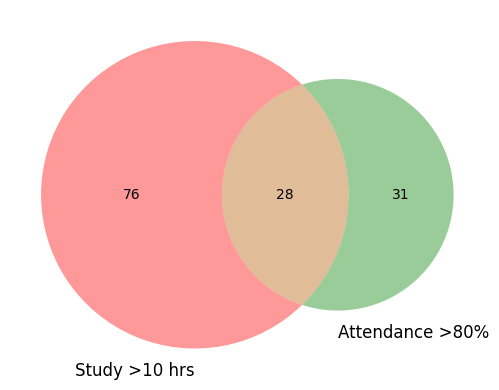

In [ ]:
from matplotlib_venn import venn2

A = set(df[df['study_hours'] > 10].index)
B = set(df[df['attendance'] > 80].index)

venn2([A, B], ('Study >10 hrs', 'Attendance >80%'))
plt.show()

In [46]:
table = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
table

final_exam_pass,Fail,Pass
group_discussion,,
No,20,81
Yes,6,93


In [49]:
joint = table.loc['Yes', 'Pass'] / len(df)
print(joint)

0.465


In [50]:
marginal = table['Pass'].sum() / len(df)
print(marginal)

0.87


In [51]:
conditional = table.loc['Yes', 'Pass'] / table.loc['Yes'].sum()
print(conditional)

0.9393939393939394


In [53]:
P_pass = pass_prob
P_fail = 1 - P_pass

P_high_given_pass = 0.70
P_high_given_fail = 0.40

P_high = (P_high_given_pass * P_pass) + (P_high_given_fail * P_fail)

bayes = (P_high_given_pass * P_pass) / P_high

print(bayes)

0.9213313161875945
